In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 103.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

In [ ]:
from glob import glob
import json
from pycocotools.coco import COCO
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import cv2

from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Explore data

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
!unzip /content/drive/MyDrive/dataset_fire_smoke.zip -d .

Archive:  /content/drive/MyDrive/dataset_fire_smoke.zip
  inflating: ./474_fire_val.zip      
  inflating: ./475_fire_train.zip    


In [ ]:
!unzip 474_fire_val.zip
!unzip 475_fire_train.zip

In [ ]:
!mkdir datasets
!mv images/ datasets/images
!mkdir datasets/labels
!mv train.json annotations/train.json
!mv annotations/instances_default.json annotations/val.json

In [ ]:
with open('annotations/train.json') as json_data:
    train_annotations = json.load(json_data)
with open('annotations/val.json') as json_data:
    val_annotations = json.load(json_data)

In [ ]:
train_annotations.keys()

dict_keys(['licenses', 'info', 'categories', 'images', 'annotations'])

In [ ]:
train_annotations['categories']

[{'id': 1, 'name': 'motorcycle', 'supercategory': ''},
 {'id': 2, 'name': 'bicycle', 'supercategory': ''},
 {'id': 3, 'name': 'wheelchair', 'supercategory': ''},
 {'id': 4, 'name': 'smoke', 'supercategory': ''},
 {'id': 5, 'name': 'fire', 'supercategory': ''},
 {'id': 6, 'name': 'scooter', 'supercategory': ''},
 {'id': 7, 'name': 'person', 'supercategory': ''}]

In [ ]:
len(val_annotations['images'])

308

In [ ]:
annFile  = "annotations/val.json"

# initialize COCO api for instance annotations
coco=COCO(annFile)

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!


In [ ]:
# display COCO categories and supercategories
cats = coco.loadCats(coco.getCatIds())
nms=[cat['name'] for cat in cats]
print('COCO categories: \n{}\n'.format(' '.join(nms)))

nms = set([cat['supercategory'] for cat in cats])
print('COCO supercategories: \n{}'.format(' '.join(nms)))

COCO categories: 
motorcycle bicycle wheelchair smoke fire scooter person

COCO supercategories: 



In [ ]:
# get all images containing given categories, select one at random
catIds = coco.getCatIds(catNms=['smoke','fire']);
imgIds = coco.getImgIds(catIds=catIds );
img = coco.loadImgs(imgIds[np.random.randint(0,len(imgIds))])[0]

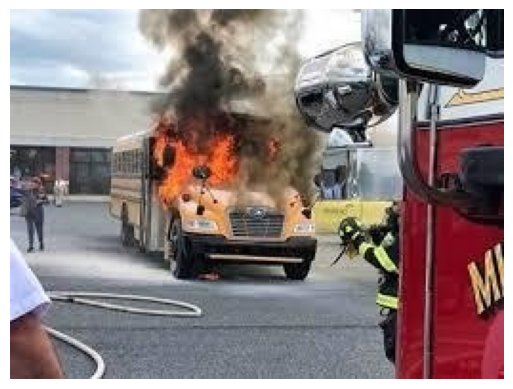

In [ ]:
# load and display image
I = Image.open(os.path.join("datasets/images", img['file_name']))
plt.axis('off')
plt.imshow(I)
plt.show()

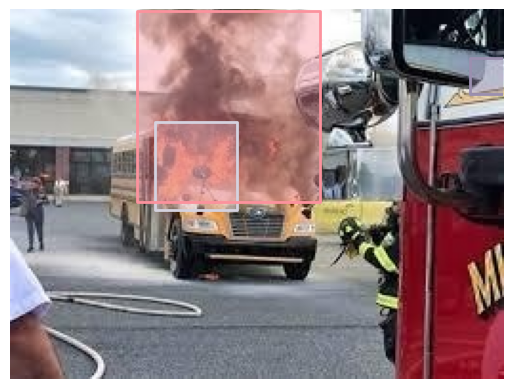

In [ ]:
# load and display instance annotations
plt.imshow(I); plt.axis('off')
annIds = coco.getAnnIds(imgIds=img['id'], catIds=catIds, iscrowd=None)
anns = coco.loadAnns(annIds)
coco.showAnns(anns, draw_bbox=True)

## Create Ultralytics dataset

In [ ]:
anns

[{'id': 1706,
  'image_id': 256,
  'category_id': 4,
  'segmentation': [],
  'area': 337.65630000000004,
  'bbox': [241.03, 25.23, 17.97, 18.79],
  'iscrowd': 0,
  'attributes': {'occluded': False, 'rotation': 0.0}},
 {'id': 1707,
  'image_id': 256,
  'category_id': 5,
  'segmentation': [],
  'area': 1981.9314000000002,
  'bbox': [75.76, 58.55, 43.02, 46.07],
  'iscrowd': 0,
  'attributes': {'occluded': False, 'rotation': 0.0}},
 {'id': 1709,
  'image_id': 256,
  'category_id': 4,
  'segmentation': [],
  'area': 9632.5452,
  'bbox': [66.09, 0.28, 96.21, 100.12],
  'iscrowd': 0,
  'attributes': {'occluded': False, 'rotation': 0.0}}]

In [ ]:
# get anns in ultralytics format
# class x_center y_center width height (normalized)

def src_to_ultralytics(img, anns):
    img_shape = cv2.imread(os.path.join("datasets/images/", img['file_name'])).shape[:2]

    new_anns = []
    for ann in anns:
        new_ann = []
        # 1 - smoke, 0 - fire
        if ann['category_id'] == 4:
            new_ann.append(1)
        elif ann['category_id'] == 5:
            new_ann.append(0)
        if len(new_ann) > 0:
            x_left, y_left, w, h = ann['bbox']
            # normalize
            x_center = (x_left + w / 2) / img_shape[1]
            y_center = (y_left + h / 2) / img_shape[0]
            w /= img_shape[1]
            h /= img_shape[0]
            new_ann.extend([x_center, y_center, w, h])
            new_anns.append(new_ann)

    return new_anns

def ultralytics_to_draw(img, anns):
    img_shape = cv2.imread(os.path.join("datasets/images/", img['file_name'])).shape[:2]

    old_anns = []
    for ann in anns:
        old_ann = []
        x_center, y_center, w, h = ann[1:]
        left = (x_center - w / 2) * img_shape[1]
        right = (x_center + w / 2) * img_shape[1]
        top = (y_center - h / 2) * img_shape[0]
        bottom = (y_center + h / 2) * img_shape[0]
        old_ann.extend([ann[0], left, top, right, bottom])
        old_anns.append(np.array(old_ann).astype(int))

    return old_anns

In [ ]:
new_anns = src_to_ultralytics(img, anns)
draw_anns = ultralytics_to_draw(img, new_anns)

In [ ]:
image = cv2.imread(os.path.join("datasets/images/", img['file_name']))[..., ::-1]

for ann in draw_anns:
    if ann[0] == 0:
        image = cv2.rectangle(image.copy(), (ann[1], ann[2]), (ann[3], ann[4]), (0, 0, 255), 2)
    elif ann[0] == 1:
        image = cv2.rectangle(image.copy(), (ann[1], ann[2]), (ann[3], ann[4]), (255, 0, 0), 2)

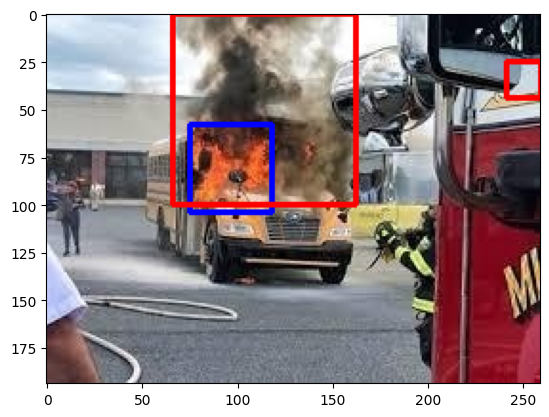

In [ ]:
plt.imshow(image)

In [ ]:
!mkdir datasets/labels/val
!mkdir datasets/labels/train

In [ ]:
annFile  = "annotations/val.json"
coco=COCO(annFile)
catIds = coco.getCatIds(catNms=['smoke','fire']);
imgIds = coco.getImgIds(catIds=catIds );

val_images = []

for img_id in imgIds:
    img = coco.loadImgs(img_id)[0]
    val_images.append(os.path.join("datasets/images", img['file_name']))
    annIds = coco.getAnnIds(imgIds=img_id, catIds=catIds, iscrowd=None)
    anns = coco.loadAnns(annIds)
    new_anns = [" ".join(map(str, x)) for x in src_to_ultralytics(img, anns)]
    with open(os.path.join("datasets/labels", img['file_name'].replace(".jpg", ".txt")), "w") as f:
        f.writelines("\n".join(new_anns))

with open("datasets/val.txt", "w") as f:
    f.writelines("\n".join(val_images))

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


In [ ]:
annFile  = "annotations/train.json"
coco=COCO(annFile)
catIds = coco.getCatIds(catNms=['smoke','fire']);
imgIds = coco.getImgIds(catIds=catIds );

train_images = []

for img_id in imgIds:
    img = coco.loadImgs(img_id)[0]
    val_images.append(os.path.join("datasets/images", img['file_name']))
    annIds = coco.getAnnIds(imgIds=img_id, catIds=catIds, iscrowd=None)
    anns = coco.loadAnns(annIds)
    new_anns = [" ".join(map(str, x)) for x in src_to_ultralytics(img, anns)]
    with open(os.path.join("datasets/labels", img['file_name'].replace(".jpg", ".txt")), "w") as f:
        f.writelines("\n".join(new_anns))

with open("datasets/train.txt", "w") as f:
    f.writelines("\n".join(val_images))

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!


## Dataset from Roboflow
https://universe.roboflow.com/middle-east-tech-university/fire-and-smoke-detection-hiwia/dataset/2

In [ ]:
!unzip /content/drive/MyDrive/fire\ and\ smoke\ detection.v2i.yolov11.zip -d .

Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: ./train/labels/youtube-34_jpg.rf.e6f154bb539745ff2777723b6778fb72.txt  
  inflating: ./train/labels/youtube-34_jpg.rf.ea9302c8ebd2490dc807b92c021ec47b.txt  
  inflating: ./train/labels/youtube-34_jpg.rf.f80c284be82caff2bad7c8eaa7d90deb.txt  
  inflating: ./train/labels/youtube-34_jpg.rf.ffcee5c89c0f6b478f5ad2e9dc8f5657.txt  
  inflating: ./train/labels/youtube-350_jpg.rf.24f37726dd270963fd16a7091227f0e1.txt  
  inflating: ./train/labels/youtube-350_jpg.rf.4e206ebf8fd2dd20b04fab723e789b17.txt  
  inflating: ./train/labels/youtube-350_jpg.rf.8476513a339eedbcb1a1c46358e415dc.txt  
  inflating: ./train/labels/youtube-351_jpg.rf.000231fa337fdaac281ebbd680ac147a.txt  
  inflating: ./train/labels/youtube-351_jpg.rf.547689cb62cdc33a735dd0267f5988b2.txt  
  inflating: ./train/labels/youtube-351_jpg.rf.9b7930ab59f5b067154d16023127675f.txt  
  inflating: ./train/labels/youtube-352_jpg.rf.2d46ee14836945cd30efab4d8871d

In [ ]:
model = YOLO("yolo11m.pt")

100%|██████████| 38.8M/38.8M [00:00<00:00, 105MB/s] 


In [ ]:
model.train(data='data.yaml',
            project='runs/baseline', name='pretrain', exist_ok=True,
            epochs=20, batch = 16, lr0=1e-4, plots=True, mosaic=0)

Ultralytics 8.3.117 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11m.pt, data=data.yaml, epochs=20, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=runs/baseline, name=pretrain, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True, line_width=None, 

train: Scanning /content/train/labels.cache... 13423 images, 0 backgrounds, 0 corrupt: 100%|██████████| 13423/13423 [00:00<?, ?it/s]


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 454.2±136.6 MB/s, size: 143.5 KB)


val: Scanning /content/valid/labels.cache... 1277 images, 1 backgrounds, 0 corrupt: 100%|██████████| 1277/1277 [00:00<?, ?it/s]


Plotting labels to runs/baseline/pretrain/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.0001' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001667, momentum=0.9) with parameter groups 106 weight(decay=0.0), 113 weight(decay=0.0005), 112 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to runs/baseline/pretrain
Starting training for 20 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      10/20      8.64G     0.9564     0.9135      1.215         52        640: 100%|██████████| 839/839 [07:52<00:00,  1.77it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 40/40 [00:18<00:00,  2.21it/s]

                   all       1277       3931      0.388      0.264      0.253     0.0888


Closing dataloader mosaic
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      11/20      8.59G      0.957     0.9094      1.216         45        640:  49%|████▊     | 407/839 [03:50<04:04,  1.76it/s]
Exception in thread Thread-42 (_pin_memory_loop):
Traceback (most recent call last):
  File "/usr/lib/python3.11/threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.11/threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/_utils/pin_memory.py", line 59, in _pin_memory_loop
    do_one_step()
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/_utils/pin_memory.py", line 35, in do_one_step
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torch/multiprocessing/reductions.py",

KeyboardInterrupt: 

## Train Ultralytics YOLOv11 as baseline

In [ ]:
model = YOLO("/content/runs/baseline/pretrain/weights/best.pt")

In [ ]:
model.train(data='new_data.yaml',
            project='runs/baseline', name='train_1', exist_ok=True,
            epochs=40, batch = 16, lr0=1e-4, plots=True, mosaic=0)

Best metrics \
Box(P          R      mAP50  mAP50-95): \
all 0.593      0.423      0.429      0.208 \
smoke       0.617      0.334      0.362      0.163 \
fire        0.568      0.513      0.496      0.254

## D-Fire dataset

In [ ]:
!unzip drive/MyDrive/D-Fire.zip -d .

In [ ]:
!mv test/images/* valid/images/
!mv test/labels/* valid/labels/

In [ ]:
model = YOLO("yolo11s.pt")

model.train(data='data.yaml',
            project='runs/baseline', name='pretrain', exist_ok=True,
            epochs=5, batch = 16, lr0=1e-4, plots=True, mosaic=0)

In [ ]:
model = YOLO("/content/runs/baseline/pretrain/weights/best.pt")

model.train(data='new_data.yaml',
            project='runs/baseline', name='train_1', exist_ok=True,
            epochs=20, batch = 16, lr0=1e-4, plots=True, mosaic=0)

Best metrics \
Box(P          R      mAP50  mAP50-95): \
                   all        0.575      0.398      0.412      0.205 \
                  fire        0.541      0.285      0.311      0.146 \
                 smoke        0.609       0.51      0.513      0.265

## YOLOv5 pretrained on D-Fire

In [ ]:
model = YOLO("/content/drive/MyDrive/yolov5s.pt")

model.train(data='new_data.yaml',
            project='runs/baseline', name='train_2', exist_ok=True,
            epochs=40, batch = 16, lr0=1e-4, plots=True, mosaic=0)

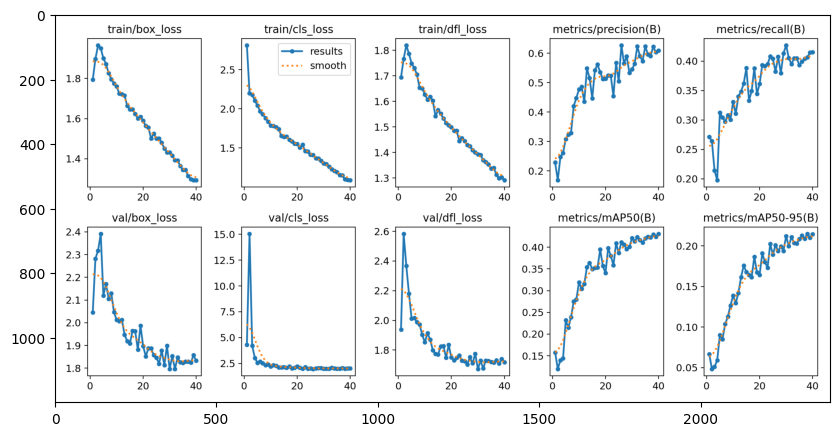

In [ ]:
results = plt.imread("runs/baseline/train_2/results.png")
fig = plt.figure(figsize=(10, 10))
plt.imshow(results)

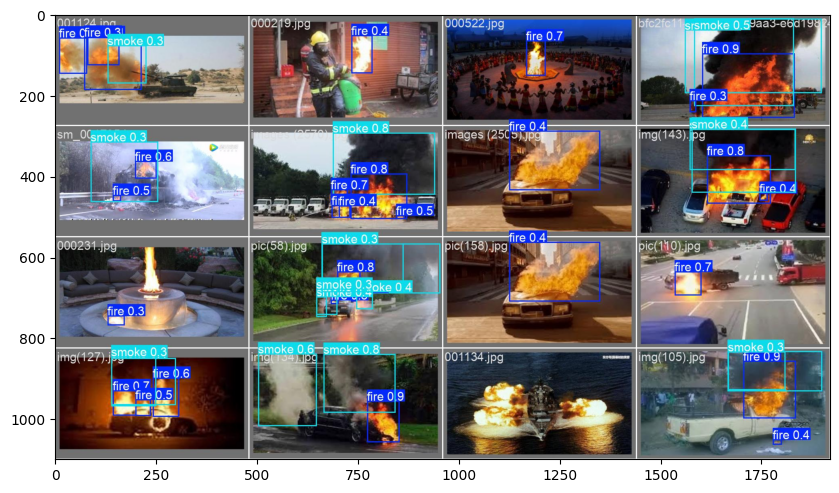

In [ ]:
results = plt.imread("/content/runs/baseline/train_2/val_batch0_pred.jpg")
fig = plt.figure(figsize=(10, 10))
plt.imshow(results)

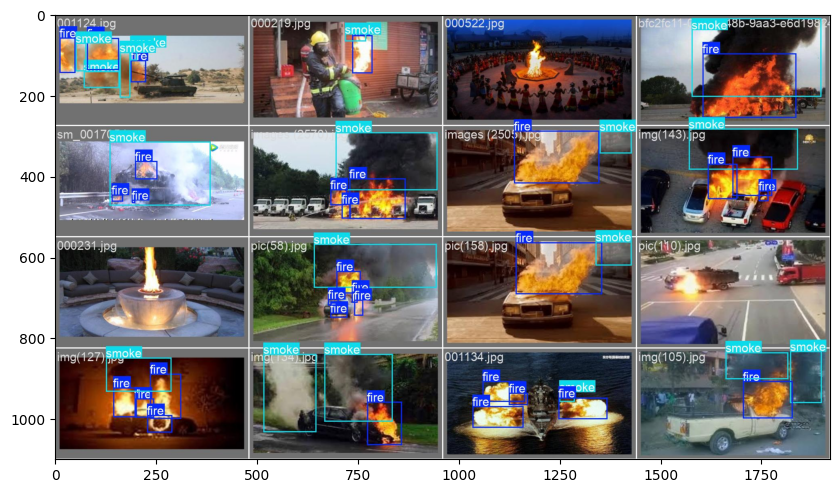

In [ ]:
results = plt.imread("/content/runs/baseline/train_2/val_batch0_labels.jpg")
fig = plt.figure(figsize=(10, 10))
plt.imshow(results)

Best metrics \
Box(P          R      mAP50  mAP50-95):  \
                   **all**      0.619      0.406      0.429      0.215 \
                  **fire**        0.588      0.489      0.506      0.268 \
                 **smoke**       0.65      0.324      0.352      0.162

## Скорость работы

In [ ]:
model = YOLO("/content/yolov11s-fire-smoke-best-pretrain.pt")

In [ ]:
from time import perf_counter
import numpy as np
import torch

def latency_benchmark(model, test_input, warmup_n=10, benchmark_n=100):
    # model - модель для замеров
    # test_input - тестовый пример
    # warmup_n - кол-во шагов для warmup
    # benchmark_n - кол-во шагов для замера латенси

    for _ in range(warmup_n):
        model(test_input)

    torch.cuda.synchronize()

    stats = []
    for _ in range(benchmark_n):
        t_0 = perf_counter()
        model(test_input)
        torch.cuda.synchronize()
        t_1 = perf_counter()
        stats.append(t_1 - t_0)

    stats = np.asarray(stats) * 1000

    mean_ms = stats.mean()
    std_ms = stats.std()

    print(f"{mean_ms:.3f}ms +- {std_ms:.3f}ms")

In [ ]:
img = cv2.imread("datasets/images/val/000016.jpg")

boxes = model(img, conf=0.4, iou=0.8, augment=True)


0: 448x640 (no detections), 33.5ms
Speed: 4.4ms preprocess, 33.5ms inference, 0.7ms postprocess per image at shape (1, 3, 448, 640)


In [ ]:
latency_benchmark(model, img, warmup_n=10, benchmark_n=100)